In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/DataCoSupplyChainDataset.csv", encoding="latin-1")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [4]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [5]:
df.isna().sum()[df.isna().sum() > 1]

Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64

In [6]:
df.shape

(180519, 53)

In [7]:
df_numerical = df.select_dtypes(exclude='category')

In [8]:
df_numerical.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

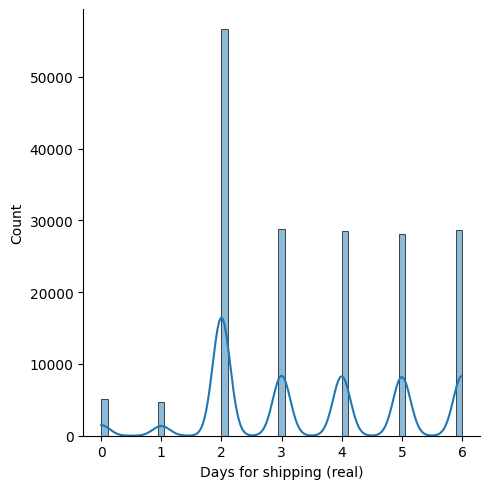

In [9]:
def plot_histogram(variable):

    # Plot the histogram thanks to the displot function
    sns.displot( data=variable, kde=True )
    plt.show()

plot_histogram(df_numerical['Days for shipping (real)'])

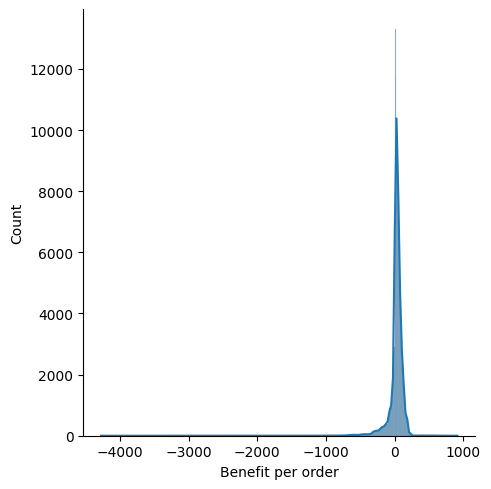

In [10]:
plot_histogram(df_numerical["Benefit per order"])

# Eventos y estados, umbrales para las variables

In [11]:
df_filtrado = df_numerical[(df_numerical["Days for shipping (real)"]>4) & (df_numerical["Benefit per order"]<=-100)]
print(df_filtrado.shape)
prob2_and = (len(df_filtrado)/len(df))

print(f"{prob2_and*100:.2f} %")

(3722, 53)
2.06 %


In [12]:
proba1 = (len(df_numerical[(df_numerical["Benefit per order"]<=-100)])/len(df))
proba2 = (len(df_numerical[(df_numerical["Days for shipping (real)"]>4)])/len(df))

for p in [proba1, proba2, proba1*proba2]:
    print(f"{p*100:.2f} %")

6.39 %
31.51 %
2.01 %


Definir que es un escenario crítico:

A: "Alto tiempo de envío"
- Days for shipping (real): >= 4
B: "Orden no rentable"
- Benefit per order: <= -100
C: "Envíos críticos no rentables y lentos"
- Days for shipping (real): >= 4 `&` Benefit per order: <= -100


In [13]:
df_critico = df_numerical[(df_numerical["Days for shipping (real)"]>=4) & (df_numerical["Benefit per order"]<=-100)]
# df es el dataset completo

In [14]:
# Probabilidades marginales
P_A = (len(df_numerical[(df_numerical["Benefit per order"]<=-100)])/len(df_numerical))
P_B = (len(df_numerical[(df_numerical["Days for shipping (real)"]>=4)])/len(df_numerical))

# Probabilidad conjunta P(A ∩ B)
P_C = len(df_numerical[(df_numerical["Days for shipping (real)"]>=4) & (df_numerical["Benefit per order"]<=-100)])/len(df_numerical)

print(f"P(A) = {P_A:.4f}  →  {P_A*100:.2f}%")
print(f"P(B) = {P_B:.4f}  →  {P_B*100:.2f}%")
print(f"P(C) = P(A∩B) = {P_C:.4f}  →  {P_C*100:.2f}%")

# Verificación: ¿son independientes?
print(f"\nP(A)·P(B) = {P_A*P_B:.4f}  (si ≈ P_C, son independientes)")

P(A) = 0.0639  →  6.39%
P(B) = 0.4731  →  47.31%
P(C) = P(A∩B) = 0.0306  →  3.06%

P(A)·P(B) = 0.0302  (si ≈ P_C, son independientes)


In [15]:
# --- Probabilidades base (ya las tienes) ---
P_A = len(df_numerical[df_numerical["Benefit per order"] <= -100]) / len(df_numerical)
P_B = len(df_numerical[df_numerical["Days for shipping (real)"] >= 4]) / len(df_numerical)
P_C = len(df_numerical[
    (df_numerical["Days for shipping (real)"] >= 4) & 
    (df_numerical["Benefit per order"] <= -100)
]) / len(df_numerical)

# --- Probabilidades condicionales directas (para validar) ---
P_A_dado_B = P_C / P_B   # P(A|B): orden no rentable DADO envío lento
P_B_dado_A = P_C / P_A   # P(B|A): envío lento DADO orden no rentable

# --- Teorema de Bayes ---
# P(A|B) via Bayes
P_A_dado_B_bayes = (P_B_dado_A * P_A) / P_B

# P(B|A) via Bayes
P_B_dado_A_bayes = (P_A_dado_B * P_B) / P_A

# --- Resultados ---
print("=" * 52)
print("TEOREMA DE BAYES — Escenarios Críticos de Logística")
print("=" * 52)
print(f"\nProbabilidades marginales:")
print(f"  P(A) Orden no rentable     = {P_A:.4f}  ({P_A*100:.2f}%)")
print(f"  P(B) Envío lento           = {P_B:.4f}  ({P_B*100:.2f}%)")
print(f"  P(A∩B) Escenario crítico   = {P_C:.4f}  ({P_C*100:.2f}%)")

print(f"\nProbabilidades condicionales:")
print(f"  P(A|B) = {P_A_dado_B:.4f}  ({P_A_dado_B*100:.2f}%)")
print(f"    → Dado envío lento, prob. de orden no rentable")
print(f"  P(B|A) = {P_B_dado_A:.4f}  ({P_B_dado_A*100:.2f}%)")
print(f"    → Dado orden no rentable, prob. de envío lento")

print(f"\nVerificación Bayes (deben coincidir):")
print(f"  P(A|B) directo vs Bayes = {P_A_dado_B:.4f} vs {P_A_dado_B_bayes:.4f}")
print(f"  P(B|A) directo vs Bayes = {P_B_dado_A:.4f} vs {P_B_dado_A_bayes:.4f}")

print(f"\nIndependencia:")
print(f"  P(A)·P(B) = {P_A*P_B:.4f}  vs  P(A∩B) = {P_C:.4f}")
if abs(P_A * P_B - P_C) < 0.001:
    print("  → Eventos aproximadamente INDEPENDIENTES")
else:
    print("  → Eventos NO independientes (hay asociación)")

TEOREMA DE BAYES — Escenarios Críticos de Logística

Probabilidades marginales:
  P(A) Orden no rentable     = 0.0639  (6.39%)
  P(B) Envío lento           = 0.4731  (47.31%)
  P(A∩B) Escenario crítico   = 0.0306  (3.06%)

Probabilidades condicionales:
  P(A|B) = 0.0648  (6.48%)
    → Dado envío lento, prob. de orden no rentable
  P(B|A) = 0.4793  (47.93%)
    → Dado orden no rentable, prob. de envío lento

Verificación Bayes (deben coincidir):
  P(A|B) directo vs Bayes = 0.0648 vs 0.0648
  P(B|A) directo vs Bayes = 0.4793 vs 0.4793

Independencia:
  P(A)·P(B) = 0.0302  vs  P(A∩B) = 0.0306
  → Eventos aproximadamente INDEPENDIENTES


In [16]:
# ================================================
# PROBABILIDADES MARGINALES Y CONJUNTAS BASE
# ================================================
P_A   = (df_numerical["Days for shipping (real)"] >= 4).mean()
P_B   = (df_numerical["Late_delivery_risk"] == 1).mean()
P_C   = (df_numerical["Benefit per order"] <= -100).mean()

# Conjuntas de dos eventos
P_AB  = ((df_numerical["Days for shipping (real)"] >= 4) &
         (df_numerical["Late_delivery_risk"] == 1)).mean()

P_AC  = ((df_numerical["Days for shipping (real)"] >= 4) &
         (df_numerical["Benefit per order"] <= -100)).mean()

P_BC  = ((df_numerical["Late_delivery_risk"] == 1) &
         (df_numerical["Benefit per order"] <= -100)).mean()

# Conjunta de los tres eventos
P_ABC = ((df_numerical["Days for shipping (real)"] >= 4) &
         (df_numerical["Late_delivery_risk"] == 1) &
         (df_numerical["Benefit per order"] <= -100)).mean()

# ================================================
# PROBABILIDADES CONDICIONALES — BAYES
# ================================================

# Pregunta principal: dado envío lento, prob de retraso Y pérdida
P_BC_dado_A   = P_ABC / P_A

# Verifica con Bayes: P(A|B∩C) * P(B∩C) / P(A)
P_A_dado_BC   = P_ABC / P_BC
P_BC_dado_A_bayes = (P_A_dado_BC * P_BC) / P_A

# Condicionales adicionales de interés
P_B_dado_A    = P_AB / P_A    # Dado envío lento → prob de riesgo retraso
P_C_dado_A    = P_AC / P_A    # Dado envío lento → prob de pérdida
P_C_dado_AB   = P_ABC / P_AB  # Dado envío lento Y retraso → prob de pérdida

# ================================================
# RESULTADOS
# ================================================
print("=" * 60)
print("  ANÁLISIS BAYESIANO — 3 VARIABLES")
print("=" * 60)

print(f"\n📦 Probabilidades marginales:")
print(f"  P(A) Envío lento          = {P_A:.4f}  ({P_A*100:.2f}%)")
print(f"  P(B) Riesgo de retraso    = {P_B:.4f}  ({P_B*100:.2f}%)")
print(f"  P(C) Orden no rentable    = {P_C:.4f}  ({P_C*100:.2f}%)")

print(f"\n🔗 Probabilidades conjuntas:")
print(f"  P(A∩B)   = {P_AB:.4f}  ({P_AB*100:.2f}%)")
print(f"  P(A∩C)   = {P_AC:.4f}  ({P_AC*100:.2f}%)")
print(f"  P(B∩C)   = {P_BC:.4f}  ({P_BC*100:.2f}%)")
print(f"  P(A∩B∩C) = {P_ABC:.4f}  ({P_ABC*100:.2f}%)")

print(f"\n🎯 Pregunta principal — Teorema de Bayes:")
print(f"  P(B∩C | A) directo = {P_BC_dado_A:.4f}  ({P_BC_dado_A*100:.2f}%)")
print(f"  P(B∩C | A) Bayes   = {P_BC_dado_A_bayes:.4f}  ({P_BC_dado_A_bayes*100:.2f}%)")
print(f"  → Dado envío lento, prob. de retraso Y pérdida simultáneos")

print(f"\n📊 Condicionales complementarias:")
print(f"  P(B|A)   = {P_B_dado_A:.4f} ({P_B_dado_A*100:.2f}%) → Envío lento → riesgo retraso")
print(f"  P(C|A)   = {P_C_dado_A:.4f} ({P_C_dado_A*100:.2f}%) → Envío lento → pérdida")
print(f"  P(C|A∩B) = {P_C_dado_AB:.4f} ({P_C_dado_AB*100:.2f}%) → Envío lento Y retraso → pérdida")

print(f"\n🔍 Verificación independencia:")
print(f"  P(B)·P(C)       = {P_B*P_C:.4f}  vs  P(B∩C)   = {P_BC:.4f}")
print(f"  P(A)·P(B)·P(C)  = {P_A*P_B*P_C:.4f}  vs  P(A∩B∩C) = {P_ABC:.4f}")

  ANÁLISIS BAYESIANO — 3 VARIABLES

📦 Probabilidades marginales:
  P(A) Envío lento          = 0.4731  (47.31%)
  P(B) Riesgo de retraso    = 0.5483  (54.83%)
  P(C) Orden no rentable    = 0.0639  (6.39%)

🔗 Probabilidades conjuntas:
  P(A∩B)   = 0.3393  (33.93%)
  P(A∩C)   = 0.0306  (3.06%)
  P(B∩C)   = 0.0351  (3.51%)
  P(A∩B∩C) = 0.0221  (2.21%)

🎯 Pregunta principal — Teorema de Bayes:
  P(B∩C | A) directo = 0.0467  (4.67%)
  P(B∩C | A) Bayes   = 0.0467  (4.67%)
  → Dado envío lento, prob. de retraso Y pérdida simultáneos

📊 Condicionales complementarias:
  P(B|A)   = 0.7172 (71.72%) → Envío lento → riesgo retraso
  P(C|A)   = 0.0648 (6.48%) → Envío lento → pérdida
  P(C|A∩B) = 0.0651 (6.51%) → Envío lento Y retraso → pérdida

🔍 Verificación independencia:
  P(B)·P(C)       = 0.0350  vs  P(B∩C)   = 0.0351
  P(A)·P(B)·P(C)  = 0.0166  vs  P(A∩B∩C) = 0.0221


In [17]:
df_numerical["Delivery Status"].value_counts("%")


Delivery Status
Late delivery        0.548291
Advance shipping     0.230402
Shipping on time     0.178352
Shipping canceled    0.042954
Name: proportion, dtype: float64

In [18]:
df_critico['Delivery Status'].value_counts()

Delivery Status
Late delivery        3985
Shipping on time     1305
Shipping canceled     241
Name: count, dtype: int64

# Muestreo aleatorio simple

In [19]:
df_muestra = df.sample(frac=0.05)
print(df_muestra.shape)

(9026, 53)


In [20]:
df_muestra.sample(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
32434,DEBIT,3,4,23.620001,118.080002,Advance shipping,0,35,Golf Gloves,Caguas,...,NaN,778,35,NaN,http://images.acmesports.sports/Bag+Boy+Bevera...,Bag Boy Beverage Holder,24.990000,0,7/13/2015 0:05,Standard Class
19959,PAYMENT,0,0,190.070007,395.980011,Shipping on time,0,45,Fishing,Alpharetta,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/9/2016 13:03,Same Day
83951,DEBIT,6,4,34.639999,106.589996,Late delivery,1,18,Men's Footwear,Chicago,...,NaN,403,18,NaN,http://images.acmesports.sports/Nike+Men%27s+C...,Nike Men's CJ Elite 2 TD Football Cleat,129.990005,0,5/21/2015 3:18,Standard Class
117676,TRANSFER,1,0,46.040001,97.959999,Late delivery,1,40,Accessories,Bronx,...,NaN,886,40,NaN,http://images.acmesports.sports/Team+Golf+San+...,Team Golf San Francisco Giants Putter Grip,24.990000,0,12/17/2015 10:48,Same Day
155584,PAYMENT,3,4,-44.990002,299.950012,Advance shipping,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,8/12/2017 22:19,Standard Class


In [21]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  str           
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  str           
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  str           
 9   Customer City                  180519 non-null  str           
 10  Customer Country               180519 non-null  str           
 11  Customer Em

In [23]:
df_muestra.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,9026.000000,9026.000000,9026.000000,9026.000000,9026.000000,9026.000000,9026.000000,9026.000000,9026.000000,9026.000000,...,9026.000000,9026.000000,9026.000000,9026.000000,1294.000000,9026.000000,9026.000000,0.0,9026.000000,9026.0
mean,3.498671,2.932307,20.757172,182.601429,0.551961,31.754930,6740.591957,36409.805340,5.439065,29.769283,...,2.107800,203.498400,182.601429,20.757172,55720.106646,690.602371,31.754930,NaN,141.614252,0.0
std,1.630746,1.375594,108.907708,123.132592,0.497320,15.646291,4140.878707,37757.323924,1.640991,9.848420,...,1.445065,136.094463,123.132592,108.907708,32544.487948,337.438950,15.646291,NaN,142.527944,0.0
min,0.000000,0.000000,-1800.000000,9.230000,0.000000,2.000000,2.000000,603.000000,2.000000,-33.937553,...,1.000000,11.290000,9.230000,-1800.000000,1841.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,6.880000,103.989998,0.000000,18.000000,3311.500000,725.000000,4.000000,18.265040,...,1.000000,119.980003,103.989998,6.880000,22845.750000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,30.940001,163.929993,1.000000,29.000000,6560.500000,20020.000000,5.000000,33.126915,...,1.000000,199.919998,163.929993,30.940001,60331.500000,627.000000,29.000000,NaN,84.400002,0.0
75%,5.000000,4.000000,64.687502,245.979996,1.000000,45.000000,9820.750000,78583.750000,7.000000,39.292454,...,3.000000,299.950012,245.979996,64.687502,90036.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,720.000000,1889.989990,1.000000,76.000000,20756.000000,99205.000000,12.000000,48.770958,...,5.000000,1999.989990,1889.989990,720.000000,98661.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [24]:
col = 'Sales per customer'

print(f"La media de '{col}' es: {df_muestra['Sales per customer'].mean():.2f}")
print(f"La desviación estándar de '{col}' es: {df_muestra['Sales per customer'].std():.2f}")

SE = df_muestra['Sales per customer'].std() / len(df_muestra)

Z_alpha_medios = 1.96

Error = SE * Z_alpha_medios

IC = {'L': df_muestra['Sales per customer'].mean()-Error, 'U': df_muestra['Sales per customer'].mean()+Error}

print(f"El intervalo de confianza es de L: {IC['L']:2.2f}, U: {IC['U']:2.2f}")


La media de 'Sales per customer' es: 182.60
La desviación estándar de 'Sales per customer' es: 123.13
El intervalo de confianza es de L: 182.57, U: 182.63
